In [1]:
import os 
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/shogohuangg/training-scaffold/2186.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2247.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2201.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2201.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2231.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2247.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2186.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2213.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2231.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2213.csv


2.10.0+cu128
True
Detected audio files: ['/kaggle/input/datasets/shogohuangg/training-scaffold/2186.wav', '/kaggle/input/datasets/shogohuangg/training-scaffold/2201.wav', '/kaggle/input/datasets/shogohuangg/training-scaffold/2213.wav', '/kaggle/input/datasets/shogohuangg/training-scaffold/2231.wav', '/kaggle/input/datasets/shogohuangg/training-scaffold/2247.wav']
Detected notation files: ['/kaggle/input/datasets/shogohuangg/training-scaffold/2186.csv', '/kaggle/input/datasets/shogohuangg/training-scaffold/2201.csv', '/kaggle/input/datasets/shogohuangg/training-scaffold/2213.csv', '/kaggle/input/datasets/shogohuangg/training-scaffold/2231.csv', '/kaggle/input/datasets/shogohuangg/training-scaffold/2247.csv']
Spectrogram shape: torch.Size([1, 1025, 300])
Piano roll shape: torch.Size([300, 88])


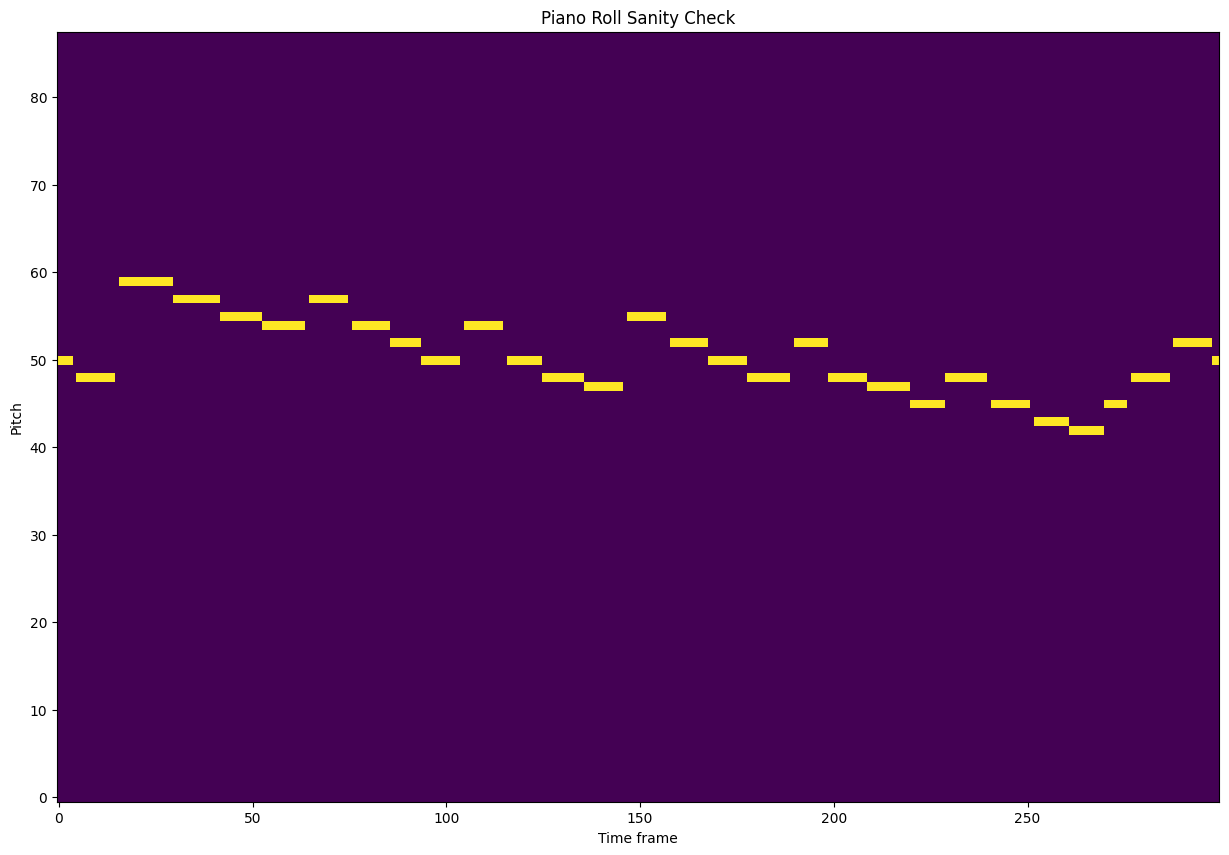

CRNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=(4, 1), stride=(4, 1), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=(4, 1), stride=(4, 1), padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(1024, 128, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=88, bias=True)
)
torch.Size([1, 300, 88])
pos_weight: 20.0
Epoch [10/3000], Train Loss: 0.3656, Test Loss: 0.9340
Epoch [20/3000], Train Loss: 0.2166, Test Loss: 1.3973
Epoch [30/3000], Train Loss: 0.2047, Test Loss: 1.6914
Epoch [40/3000], Train Loss: 0.2024, Test Loss: 1.8327
Epoch [50/3000], Tra

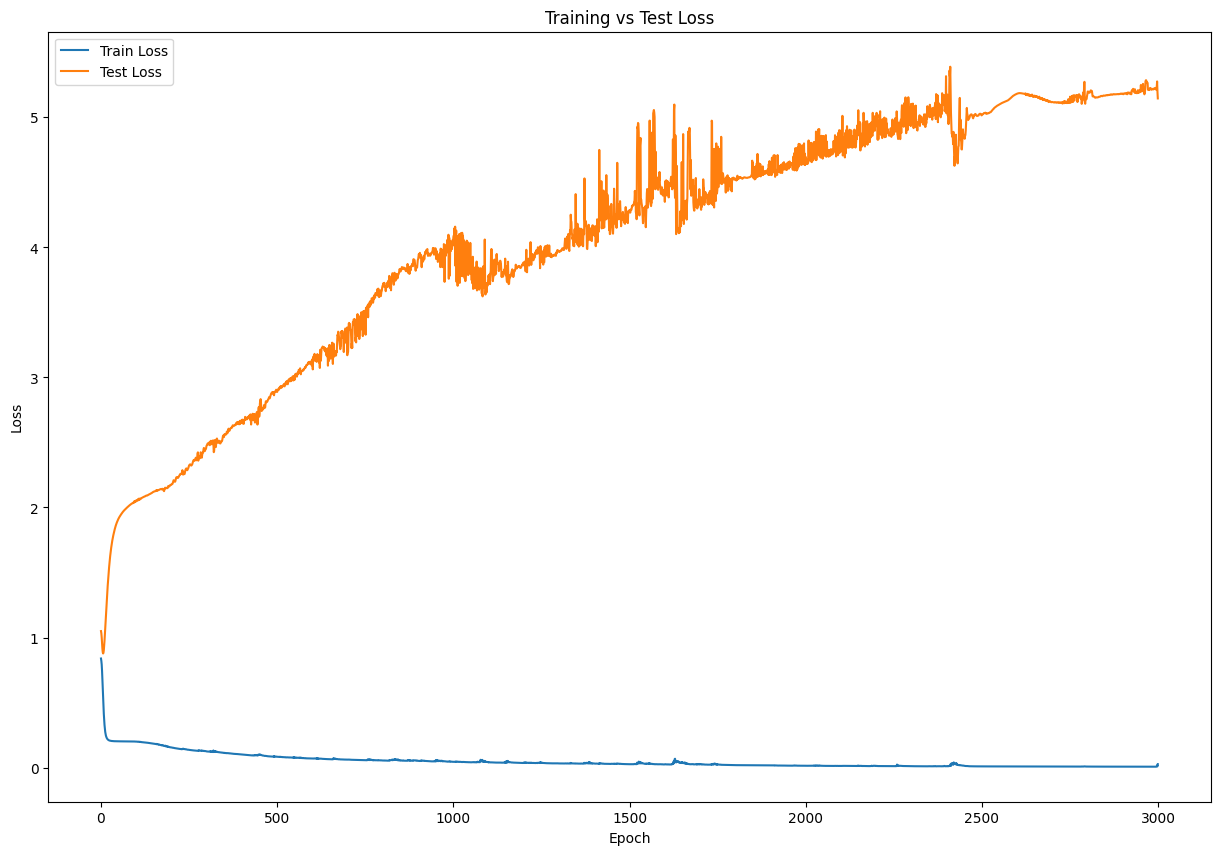

probs min/max/mean: 1.4605818776658452e-09 0.9998857975006104 0.013325447216629982
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')


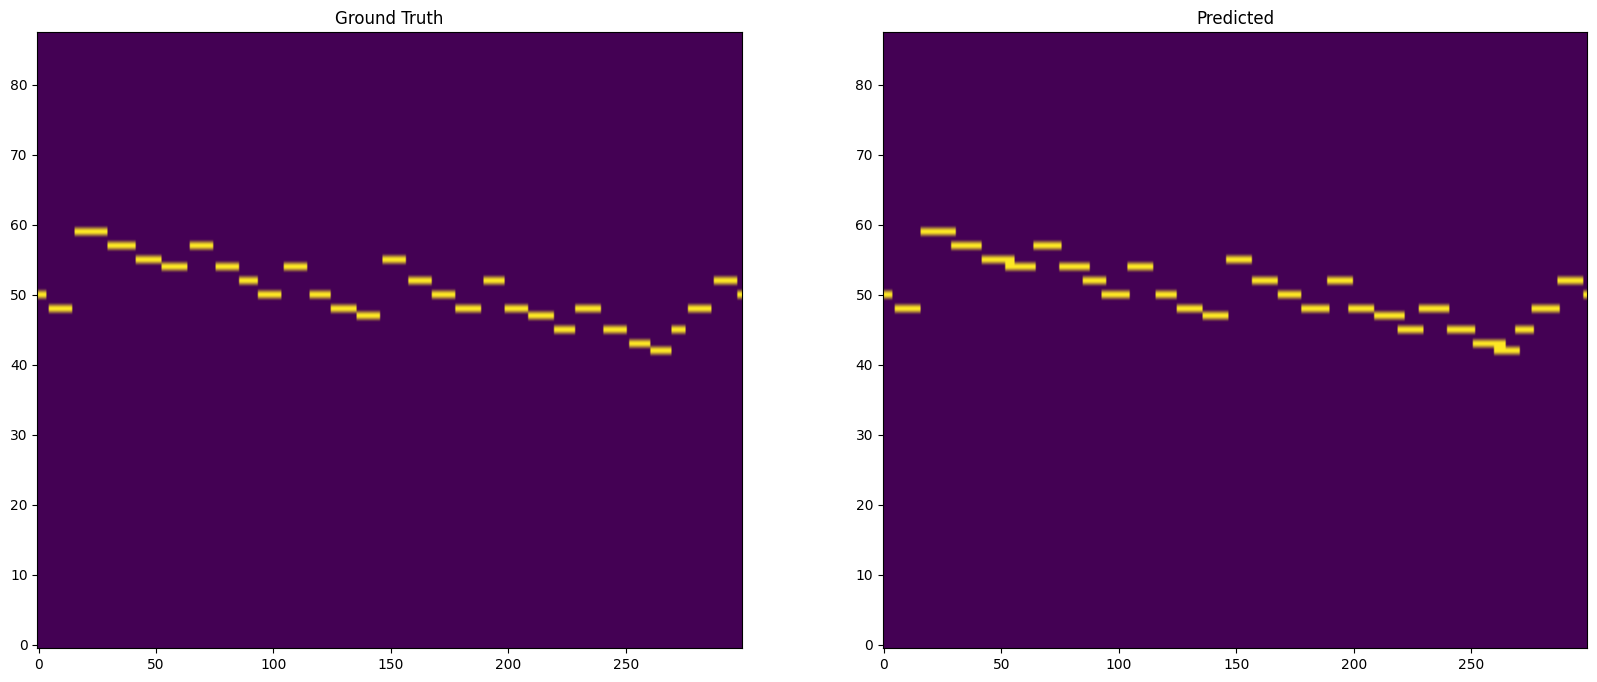

My recording spectrogram shape: torch.Size([1, 1025, 20968])
Predicted output shape: torch.Size([1, 20968, 88])


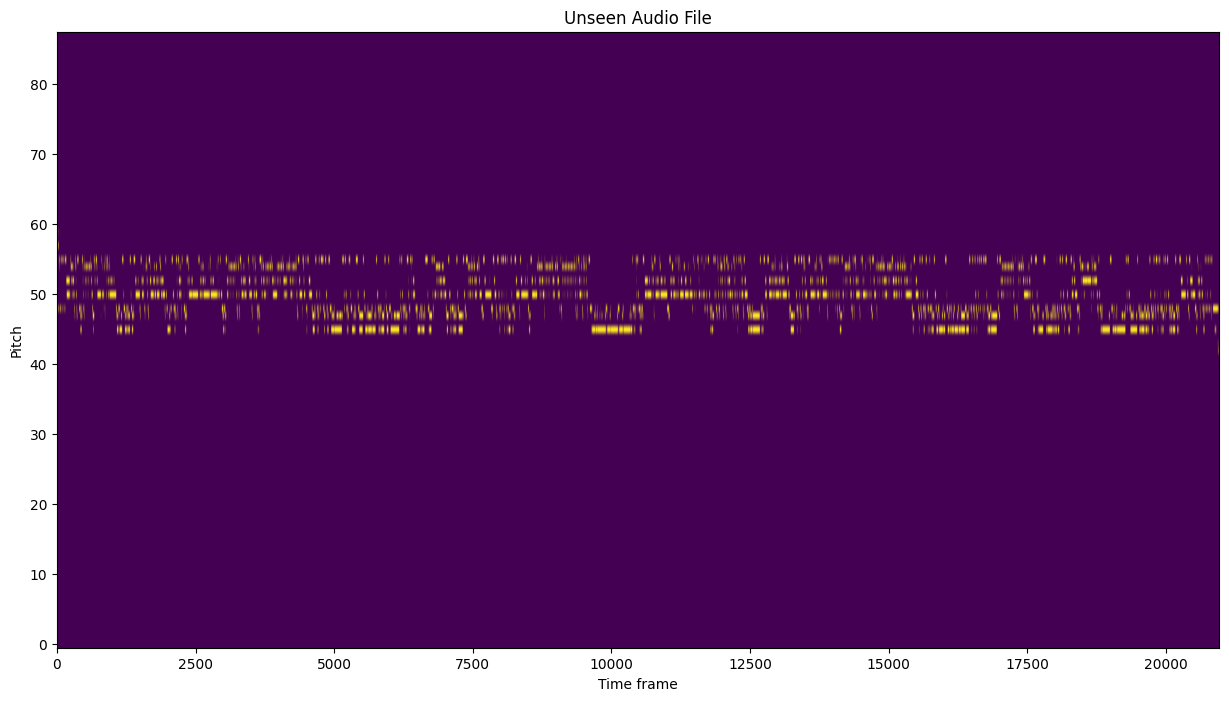

In [1]:
import torch
import librosa
import soundfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

print(torch.__version__)
print(torch.cuda.is_available())

data_dir = "/kaggle/input/datasets/shogohuangg/training-scaffold"

audio_files = [
    f"{data_dir}/2186.wav", f"{data_dir}/2201.wav", f"{data_dir}/2213.wav",
    f"{data_dir}/2231.wav", f"{data_dir}/2247.wav"
]
notation_files = [
    f"{data_dir}/2186.csv", f"{data_dir}/2201.csv", f"{data_dir}/2213.csv",
    f"{data_dir}/2231.csv", f"{data_dir}/2247.csv"
]

print("Detected audio files:", audio_files)
print("Detected notation files:", notation_files)


class MusicDataset(Dataset):
    def __init__(self, audio_files, label_files):
        self.audio_files = audio_files
        self.label_files = label_files

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, index):
        audio_path = self.audio_files[index]
        label_path = self.label_files[index]
        y, sr = librosa.load(audio_path, sr=None)
        D = librosa.stft(y)
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)
        spectrogram_tensor = torch.tensor(S_db, dtype=torch.float32)
        spectrogram_tensor = spectrogram_tensor.unsqueeze(0)

        labels_df = pd.read_csv(label_path)
        hop_length = 512
        n_frame = spectrogram_tensor.shape[-1]
        piano_roll = torch.zeros(n_frame, 88)

        for _, row in labels_df.iterrows():
            start_frame = int(row['start_time']) // hop_length
            end_frame = int(row['end_time']) // hop_length
            pitch_idx = int(row['note']) - 21
            if 0 <= pitch_idx < 88:
                piano_roll[start_frame:end_frame, pitch_idx] = 1

        chunk_len = 300
        total_frames = spectrogram_tensor.shape[-1]
        start = np.random.randint(0, max(1, total_frames - chunk_len))
        spectrogram_tensor = spectrogram_tensor[:, :, start:start+chunk_len]
        piano_roll = piano_roll[start:start+chunk_len, :]

        return spectrogram_tensor, piano_roll


train_dataset = MusicDataset(audio_files[:4], notation_files[:4])
test_dataset = MusicDataset(audio_files[4:], notation_files[4:])
dataset = train_dataset
spectrogram, piano_roll = dataset[0]
print("Spectrogram shape:", spectrogram.shape)
print("Piano roll shape:", piano_roll.shape)

plt.figure(figsize=(15,10))
plt.imshow(piano_roll.T, aspect='auto', origin='lower')
plt.xlabel("Time frame")
plt.ylabel("Pitch")
plt.title("Piano Roll Sanity Check")
plt.show()


class CRNN(nn.Module):
    def __init__(self, num_freq_bins=1025, cnn_channels=16, hidden_size=128, num_classes=88):
        super(CRNN, self).__init__()
        self.conv1 = nn.Conv2d(1, cnn_channels, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d((2,1))   

        self.conv2 = nn.Conv2d(cnn_channels, cnn_channels*2, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d((4,1))  

        self.conv3 = nn.Conv2d(cnn_channels*2, cnn_channels*2, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d((4,1))

        lstm_input = cnn_channels*2*32  

        self.lstm = nn.LSTM(input_size=lstm_input, hidden_size=hidden_size, num_layers=2,
                             batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        batch_size, channels, freq, time = x.shape
        x = x.permute(0,3,1,2).reshape(batch_size, time, channels*freq)
        x, _ = self.lstm(x)
        x = self.fc(x)
        return x


model = CRNN().cuda()
print(model)
output = model(spectrogram.unsqueeze(0).cuda())
print(output.shape)


epochs = 3000
train_loss_history = []
test_loss_history = []

spectrogram = spectrogram.unsqueeze(0).cuda()
piano_roll = piano_roll.unsqueeze(0).cuda()

test_spectrogram, test_piano_roll = test_dataset[0]
test_spectrogram = test_spectrogram.unsqueeze(0).cuda()
test_piano_roll = test_piano_roll.unsqueeze(0).cuda()

num_pos = piano_roll.sum()
num_neg = piano_roll.numel() - num_pos
pos_weight = (num_neg/num_pos).clone().detach().cuda()
pos_weight = torch.clamp(pos_weight, max=20.0)
print("pos_weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100)

best_loss = float('inf')
best_state = None

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(spectrogram)
    loss = criterion(output, piano_roll)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step(loss.item())
    train_loss_history.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_output = model(test_spectrogram)
        test_loss = criterion(test_output, test_piano_roll)
    test_loss_history.append(test_loss.item())

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

model.load_state_dict(best_state)

plt.figure(figsize=(15,10))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.plot(train_loss_history, label="Train Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.legend()
plt.show()

model.eval()
with torch.no_grad():
    output = model(spectrogram)
    probs = torch.sigmoid(output)
    print("probs min/max/mean:", probs.min().item(), probs.max().item(), probs.mean().item())
    preds = (probs > 0.5).float()
    print(preds)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(piano_roll.squeeze(0).cpu().T, aspect='auto', origin='lower')
axes[0].set_title("Ground Truth")
axes[1].imshow(preds.squeeze(0).cpu().T, aspect='auto', origin='lower')
axes[1].set_title("Predicted")
plt.show()

shogo_audio = "/kaggle/input/datasets/shogohuangg/training-scaffold/Thais.wav"

y, sr = librosa.load(shogo_audio, sr=None)
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)
my_spectrogram = torch.tensor(S_db, dtype=torch.float32)
my_spectrogram = my_spectrogram.unsqueeze(0)

print("My recording spectrogram shape:", my_spectrogram.shape)

model.eval()
with torch.no_grad():
    my_output = model(my_spectrogram.unsqueeze(0).cuda())
    my_probs = torch.sigmoid(my_output)
    my_preds = (my_probs > 0.5).float()

print("Predicted output shape:", my_preds.shape)

plt.figure(figsize=(15, 8))
plt.imshow(my_preds.squeeze(0).cpu().T, aspect='auto', origin='lower')
plt.xlabel("Time frame")
plt.ylabel("Pitch")
plt.title("Unseen Audio File")
plt.show()